# Exploratory Analysis on the Variables of the Models

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from h5n1.db import get_engine

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

## 0. What this notebook does

Primary, look-before-you-leap exploratory analysis: one plot per variable, on the raw
(untransformed) scale, before `regression_baseline.ipynb` decides how each one gets
`log1p`'d, capped, or turned into an indicator column. The variable set here matches
that notebook's **Section 0 — Define Variables** exactly, so the two are meant to be
read side by side.

This pulls a **uniform** random sample of `feature_county_day` — not the case-control
sampling the modeling notebook uses for training — so every shape below is the true
population distribution, just thinned for plotting speed.

Requires the modeling extra and a running Cloud SQL proxy:

```bash
uv sync --extra modeling --extra dev
.\cloud-sql-proxy.exe harvard-capstone-499102:us-central1:h5n1-pg --port 5433
uv run --extra modeling --extra dev jupyter lab
```

In [2]:
# --- configuration -------------------------------------------------------------

STUDY_START = "2022-02-08"   # first US poultry detection; matches regression_baseline.ipynb
SAMPLE_RATE = 0.15           # uniform sample of feature_county_day, for plotting speed only --
                              # NOT case-control, so the shapes below stay population-representative
RANDOM_STATE = 20260728

In [3]:
# --- plot style: recessive grid, thin marks, text in ink rather than series color ---
INK, INK_2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
BLUE = "#2a78d6"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9.5,
    "legend.frameon": False,
})


def hist_grid(df, cols, ncols=3, bins=40, log_y=True, clip_q=0.99, suptitle=None):
    """One histogram per column, small multiples, raw (untransformed) scale.

    Values above the clip_q quantile are folded into the rightmost bin (clipped, not
    dropped) so a handful of extreme counties don't flatten the rest of the distribution
    into a single bar, while the edge bin still shows that a tail exists -- true max is
    still in df.describe(). Missing share, if any, goes in the subplot title.
    """
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.6, nrows * 2.7))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, cols):
        s = df[col].dropna()
        hi = s.quantile(clip_q) if len(s) else 1
        lo = min(s.min(), 0) if len(s) else 0
        s_plot = s.clip(upper=hi) if hi > lo else s
        ax.hist(s_plot, bins=bins, range=(lo, hi) if hi > lo else None,
                color=BLUE, edgecolor=SURFACE, linewidth=0.3)
        if log_y:
            ax.set_yscale("log")
        miss = df[col].isna().mean()
        ax.set_title(f"{col}  (missing {miss:.1%})" if miss > 0 else col,
                     fontsize=9, color=INK)
        ax.tick_params(labelsize=7.5)
    for ax in axes[len(cols):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=11, color=INK, y=1.01)
    fig.tight_layout()
    plt.show()


def bool_bar(ax, s, title):
    """Value-count bar chart for a boolean/indicator series, annotated with row share."""
    counts = s.value_counts(dropna=False)
    counts = counts.reindex(sorted(counts.index, key=lambda v: (pd.isna(v), v)))
    labels = ["NaN" if pd.isna(v) else str(v) for v in counts.index]
    total = counts.sum()
    ax.bar(labels, counts.values, color=BLUE, width=0.6)
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v / total:.2%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    ax.set_title(title, fontsize=9.5, color=INK)
    ax.margins(y=0.15)

## 1. Load

Same two structural filters as `regression_baseline.ipynb` (`is_conus`, `target_complete_7d`)
so the target isn't distorted by Alaska/Hawaii's structural NULLs or by the truncated,
partly-fictional zeros near the data horizon — plus `STUDY_START`, since the DV is all-zero
before the first US detection. Unlike that notebook, there is **no case-control resampling**
here: the sample below is uniform across the whole population, so every variable's shape is
the real one, just thinned for plotting speed.

In [4]:
QUERY = f"""
SELECT fips, day, state,
       target_outbreak_next_7d,
       outbreak, own_outbreaks_7d, own_outbreaks_21d, own_outbreaks_60d,
       nbr_infected_counties_7d, nbr_infected_counties_21d, nbr_infected_counties_60d,
       nbr_infections_7d, nbr_infections_21d, nbr_infections_60d,
       nbr_wild_detections_7d, nbr_wild_detections_21d, nbr_wild_detections_60d,
       wild_detections_7d, wild_detections_21d, wild_detections_60d,
       band_count_21d, nbr_band_count_21d, has_band_coverage,
       days_since_outbreak_county, days_since_outbreak_neighbor,
       breeding_side_pressure, wintering_side_pressure,
       temp_min_7d_c, temp_max_7d_c, precip_7d_mm, precip_days_7d,
       poultry_operations, layer_operations, broiler_operations,
       turkey_operations, duck_operations, layer_inventory,
       population, pop_density_sqmi, n_neighbors, doy_sin, doy_cos
FROM feature_county_day
WHERE is_conus
  AND target_complete_7d
  AND day >= '{STUDY_START}'
  AND random() < {SAMPLE_RATE}
"""

df = pd.read_sql(QUERY, get_engine())
df["day"] = pd.to_datetime(df["day"])
print(f"{len(df):,} rows x {df.shape[1]} columns  ({SAMPLE_RATE:.0%} uniform sample, not case-control)")
print(f"date range {df.day.min().date()} .. {df.day.max().date()}")

753,740 rows x 42 columns  (15% uniform sample, not case-control)
date range 2022-02-08 .. 2026-07-14


## 2. Missingness

`NULL != 0` everywhere in this schema — a missing weather reading, a right-censored
recency, and a suppressed NASS inventory all mean different things and get handled
differently in the modeling notebook. This is the map of where NULLs actually are before
any of that handling happens.

findfont: Failed to find font weight 600, now using 700.


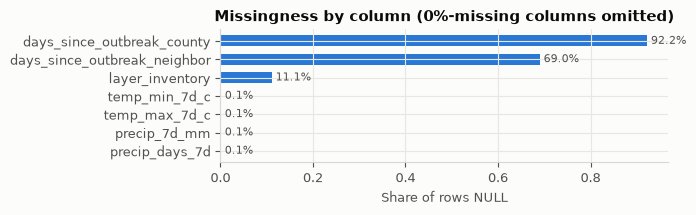

In [5]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(7, max(2.2, 0.32 * len(miss))))
ax.barh(miss.index[::-1], miss.values[::-1], color=BLUE, height=0.6)
for y, v in enumerate(miss.values[::-1]):
    ax.text(v, y, f" {v:.1%}", va="center", fontsize=8, color=INK_2)
ax.set(xlabel="Share of rows NULL", title="Missingness by column (0%-missing columns omitted)")
fig.tight_layout()
plt.show()

* Other variables that are not listed in the plot have 0% NULLs.
* Here, we see that there are many nulls in the days since outbreak county and days since outbreak neighbor.  Null here means that there is no outbreak in the past window of days (we can set the number of days, like 365 days or more) in the county or the neighboring counties.
* NULL in the layer inventory means that NASS refuses to publish inventory/sales figures when so few operations exist in a county that reporting them would let you back out an individual farm's numbers.
* Around 0.1% of 7-day temperature and precipitation min, max are NULLs. Not a big amount of NULLs that we can fill with the median temperature and precipitation or from the previous 7-day window. 

## 3. Target / outcome

`target_outbreak_next_7d` is the DV — a USDA-confirmed poultry detection anywhere in the
county over the next 7 days. `outbreak` is the same-day flag it's built from; it's only
ever legitimate as *own-history* input (via `own_outbreaks_*`), never as a same-day
predictor of itself. Both are rare-event booleans, so a bar chart of shares says more than
a histogram would.

findfont: Failed to find font weight 600, now using 700.


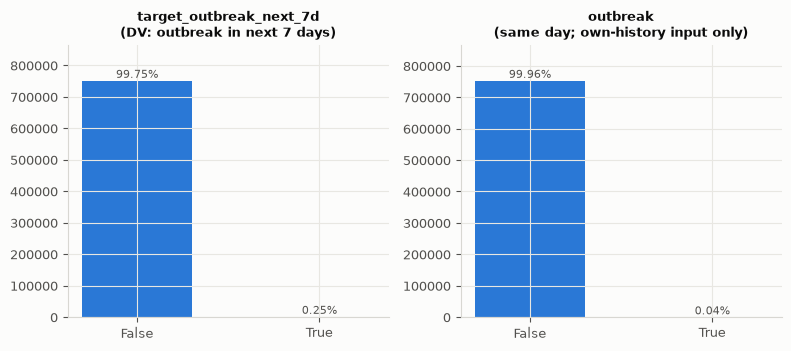

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
bool_bar(axes[0], df.target_outbreak_next_7d, "target_outbreak_next_7d\n(DV: outbreak in next 7 days)")
bool_bar(axes[1], df.outbreak, "outbreak\n(same day; own-history input only)")
fig.tight_layout()
plt.show()

* How we define the outbreak is by classifying as TRUE if there is any confirmed detection that county-day, even just a single one.
* The existence of a case detected is rare both in the present day at 0.04% and in the next 7 days at 0.25%

## 4. Own-county outbreak history & wild-bird signal

Trailing, past-only counts (`[day-w, day-1]`) at 7/21/60-day windows, raw scale. These are
sparse count facts — absence means zero — and heavily right-skewed, so the y-axis is
log-scaled to keep the non-zero tail visible against the zero spike.

findfont: Failed to find font weight 600, now using 700.


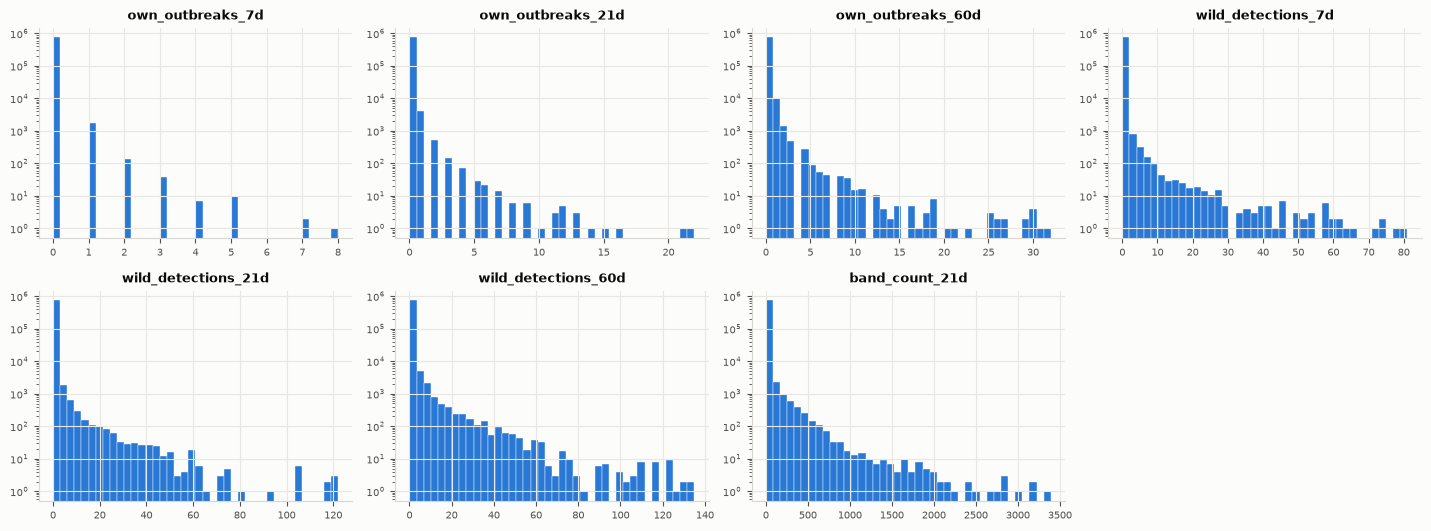

In [7]:
OWN_COLS = [
    "own_outbreaks_7d", "own_outbreaks_21d", "own_outbreaks_60d",
    "wild_detections_7d", "wild_detections_21d", "wild_detections_60d",
    "band_count_21d",
]
# clip_q=1.0 (no clipping): these are small-integer counts (max ~30), and the default
# 0.99 quantile lands right at the domain edge for such sparse events -- clipping there
# would erase real tail values instead of trimming true outliers.
hist_grid(df, OWN_COLS, ncols=4, clip_q=1.0)

* Own_outbreaks is the outbreak in a broiler flock and a layer flock.
* wild_detections is the outbreak in wild birds.
* band_count is the number of wild birds captured and tagged ("banded") by researchers in that county-day.
* Heavily right-skewed to zero counts. The own outbreaks are the production flock type from APHIS Confirmed Detections, which is comparable to the amount of wild outbreaks, which is different than the USDA commercial and backyard flocks case. 

## 5. Neighboring-county (queen-adjacency) signal

Same trailing windows, summed or counted across bordering counties: how many neighbors
were infected, how many total infection events, and how much wild-bird / banding activity
they carried.

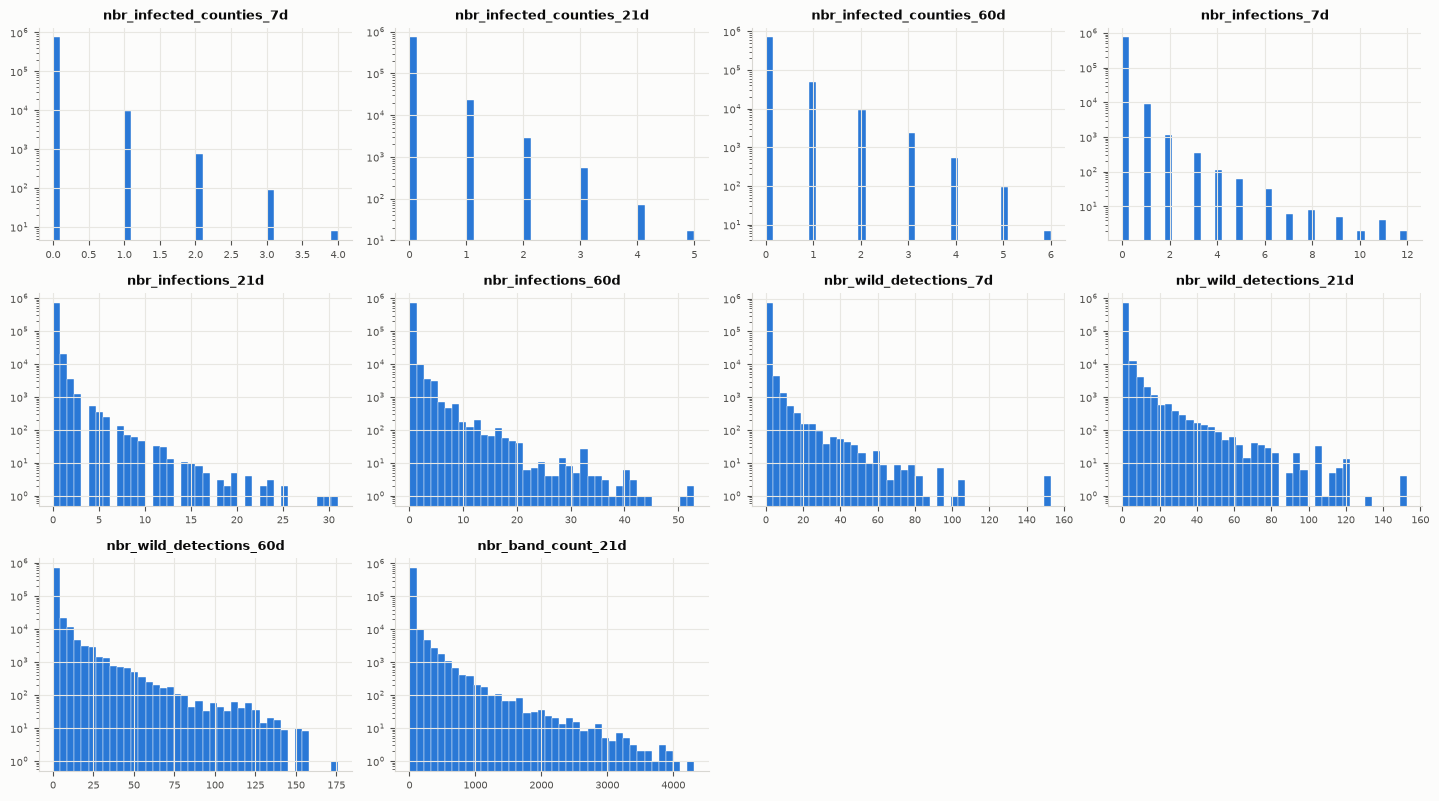

In [8]:
NBR_COLS = [
    "nbr_infected_counties_7d", "nbr_infected_counties_21d", "nbr_infected_counties_60d",
    "nbr_infections_7d", "nbr_infections_21d", "nbr_infections_60d",
    "nbr_wild_detections_7d", "nbr_wild_detections_21d", "nbr_wild_detections_60d",
    "nbr_band_count_21d",
]
# same reasoning as the own-county cell above: small-integer sparse counts, no clipping.
hist_grid(df, NBR_COLS, ncols=4, clip_q=1.0)

## 6. Migration pressure

Distance-decayed, 21-day trailing wild-bird pressure from the breeding-ground and
wintering-ground bearing sectors (`h5n1/features/migration_pressure.py`). Directional, so
these two shouldn't look identical to each other even though they share a construction.

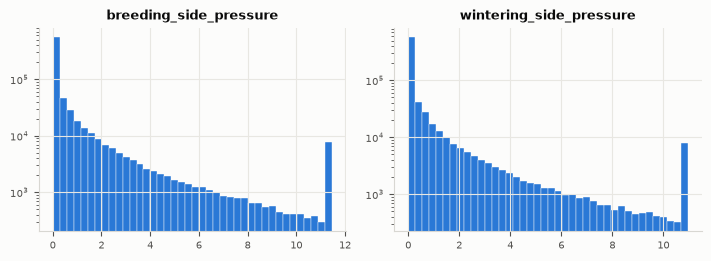

In [9]:
hist_grid(df, ["breeding_side_pressure", "wintering_side_pressure"], ncols=2)

* Breeding side pressure
    * Wider range of x-axis, high number of zeros because the majority of H5N1 is undetected, has a jump in the breeding side pressure again at 11.  

* Wintering side pressure
    * Narrower range of x-axis, high number of zeros because the majority of H5N1 is undetected, has a jump in the breeding side pressure again at 11.


* Further clarification about Breeding and Wintering side pressure


breeding_side_pressure and wintering_side_pressure are two directional versions of the same measurement: distance-weighted wild-bird H5N1 detections in the trailing 21 days, but only counted from counties that lie in a specific compass direction relative to the target county — the difference is which direction each one looks in.

The idea (h5n1/features/migration_pressure.py:1-8): infection doesn't just show up randomly — it's carried by migrating wild birds, and which direction it arrives from depends on the season. In fall, birds are flying south from their breeding grounds, so incoming pressure would come from the breeding-ground direction; in spring, they're flying north from their wintering grounds, so pressure comes from that direction instead.

How the direction is defined (h5n1/sources/migration.py:41-49): every U.S. flyway (Atlantic/Mississippi/Central/Pacific — assigned by state) has two hand-placed anchor points:

"Mississippi": {"breeding": (60.0, -100.0), "wintering": (29.0, -91.0)},

For each county, the code computes the great-circle bearing (a compass direction, degrees from north) from that county toward its flyway's breeding anchor (up in Arctic Canada) and separately toward its wintering anchor (down in the Gulf/Florida region). So a county in Mississippi flyway has a "breeding bearing" pointing roughly NNW and a "wintering bearing" pointing roughly SSE — genuinely different directions for that county, not a global north/south split.

Then the pressure itself: for each county, look at all other counties within 300 km whose bearing from you falls inside a 90°-wide cone (±45°) around your breeding bearing — sum their wild-bird detections from the past 21 days, weighted down with distance (exp(-distance/150km), so a detection 150 km away counts for ~37% of one right next door). That sum is breeding_side_pressure. Do the exact same calculation but pointed at the wintering bearing instead, and that's wintering_side_pressure.

So concretely: breeding_side_pressure = "how much recent wild-bird HPAI activity is happening in the direction of the Arctic breeding grounds relative to me," and wintering_side_pressure = "how much is happening in the direction of the southern wintering grounds relative to me." Both are computed for every county-day, always — the notebook doesn't pick one based on the calendar; the model is left to learn on its own (via doy_sin/doy_cos) that breeding-side matters more in fall and wintering-side matters more in spring.

## 7. Censored recency

`days_since_outbreak_*` is **NULL when nothing happened in the trailing 365 days** —
right-censoring, not missingness; filling it with a number would claim knowledge the data
doesn't have. Left column: share of rows censored. Right column: the raw day-count,
restricted to rows where something *did* happen in the window.

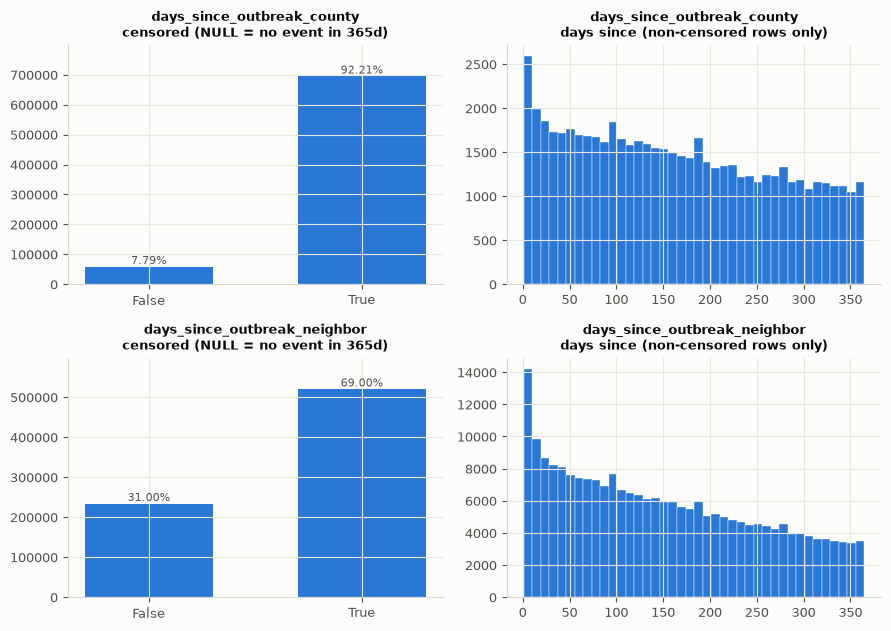

In [10]:
CENSORED_COLS = ["days_since_outbreak_county", "days_since_outbreak_neighbor"]

fig, axes = plt.subplots(2, 2, figsize=(9, 6.4))
for i, c in enumerate(CENSORED_COLS):
    bool_bar(axes[i, 0], df[c].isna(), f"{c}\ncensored (NULL = no event in 365d)")
    s = df[c].dropna()
    axes[i, 1].hist(s, bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
    axes[i, 1].set_title(f"{c}\ndays since (non-censored rows only)", fontsize=9, color=INK)
fig.tight_layout()
plt.show()

## 8. Poultry exposure (static, 2022 Census of Agriculture)

Operations counts (never suppressed, coalesced to 0) plus `layer_inventory`, which NASS
withholds for some counties — those show up as missing here, not zero. These are static
attributes repeated on every day of a county's rows, so the shape below is really a
cross-section over ~3,100 counties, not over county-days.

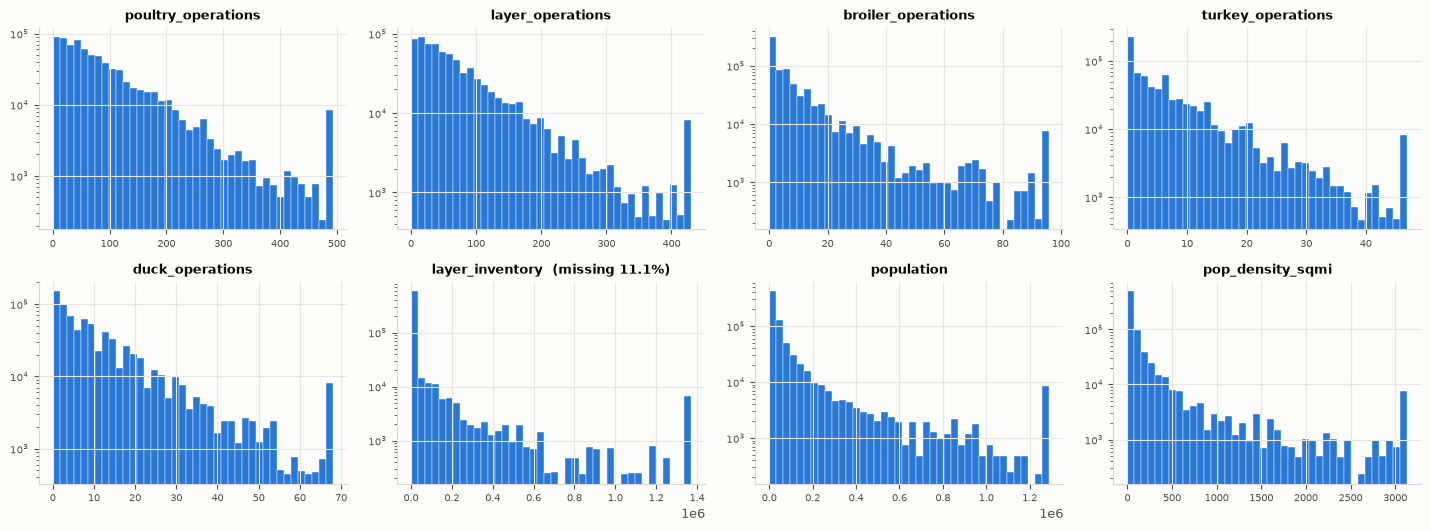

In [11]:
POULTRY_COLS = [
    "poultry_operations", "layer_operations", "broiler_operations",
    "turkey_operations", "duck_operations", "layer_inventory",
    "population", "pop_density_sqmi",
]
hist_grid(df, POULTRY_COLS, ncols=4)

## 9. Weather (trailing 7 days, inclusive of today)

A measurement, not a count: NULL means the nearest GHCN station didn't report, not "no
weather." Temperatures are roughly bell-shaped so they stay on a linear y-axis; precipitation
is zero-inflated and right-skewed like the count variables above, so it gets the log y-axis.

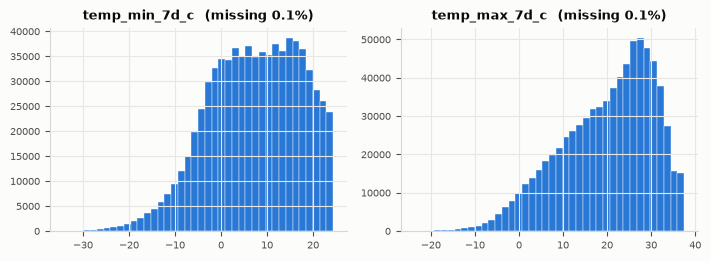

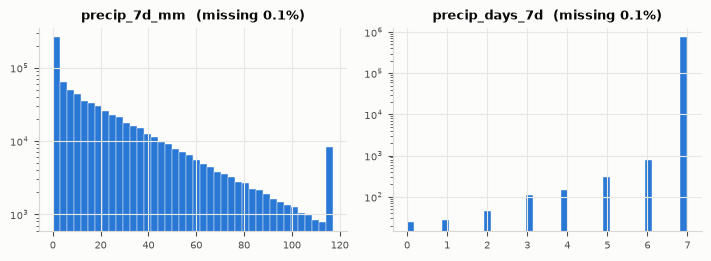

In [12]:
hist_grid(df, ["temp_min_7d_c", "temp_max_7d_c"], ncols=2, log_y=False)
hist_grid(df, ["precip_7d_mm", "precip_days_7d"], ncols=2, log_y=True)

## 10. Calendar & geography

`doy_sin`/`doy_cos` are a sanity check as much as an EDA plot: plotted against each other
they should trace a clean unit circle — if they don't, the day-of-year encoding is broken.
`n_neighbors` is a static topology feature (coastal/corner counties border fewer counties).
`has_band_coverage` flags that `fact_bird_density` stops 2025-07-10 — real coverage, not a
load bug — so this share should drop to 0 in the notebook's most recent months.

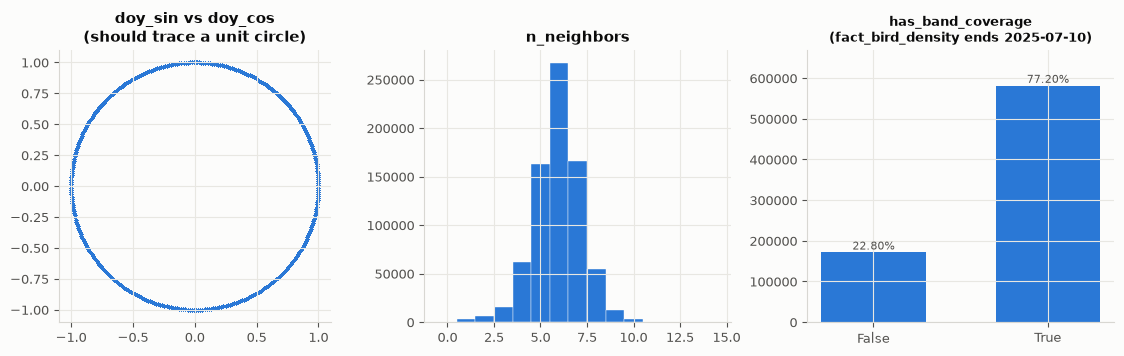

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))

axes[0].scatter(df.doy_sin, df.doy_cos, s=2, alpha=0.03, color=BLUE)
axes[0].set(title="doy_sin vs doy_cos\n(should trace a unit circle)")
axes[0].set_aspect("equal")

nmax = int(df.n_neighbors.max())
axes[1].hist(df.n_neighbors, bins=range(0, nmax + 2), color=BLUE,
             edgecolor=SURFACE, linewidth=0.3, align="left")
axes[1].set_title("n_neighbors")

bool_bar(axes[2], df.has_band_coverage, "has_band_coverage\n(fact_bird_density ends 2025-07-10)")

fig.tight_layout()
plt.show()

## 11. Categorical — state

Row counts by state in the sample — mostly a function of county count and land area, so
this is really a check that no state dropped out or got double-counted, not a substantive
finding on its own.

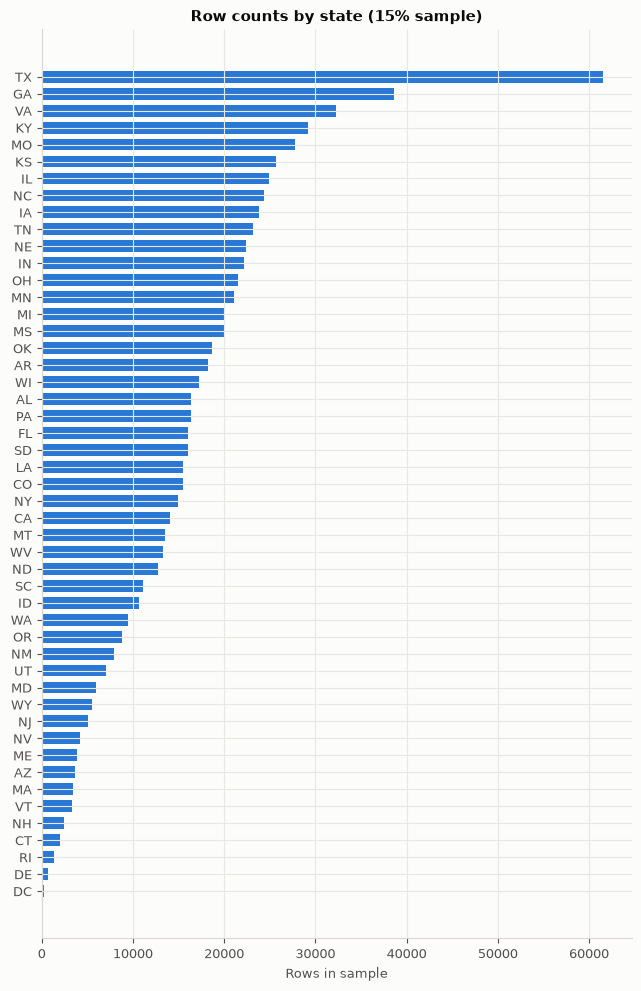

In [14]:
state_counts = df["state"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(6.5, 10))
ax.barh(state_counts.index, state_counts.values, color=BLUE, height=0.7)
ax.set(xlabel="Rows in sample", title=f"Row counts by state ({SAMPLE_RATE:.0%} sample)")
fig.tight_layout()
plt.show()